In [2]:
# ============================================
# MOVIE RATING PREDICTION WITH PYTHON
# CodSoft Data Science Internship - Task 2
# ============================================


# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns  

# Machine Learning 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.preprocessing import LabelEncoder 

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [3]:
# ============================================
# STEP 2 - DATA LOADING
# ============================================


# Load Data 
df = pd.read_csv('IMDb_Movies_India.csv', encoding='latin1')
# Basic info
print(" Dataset Loaded Successfully!")
print(f" Dataset Shape: {df.shape}")
print(f"\n Columns: {list(df.columns)}")
print(f"\n First 5 Rows:")
df.head()

 Dataset Loaded Successfully!
 Dataset Shape: (15509, 10)

 Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

 First 5 Rows:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
# ============================================
# STEP 3 - EXPLORATORY DATA ANALYSIS
# ============================================

print("=" * 50)
print(" DATASET INFO:")
print("=" * 50)
df.info()

print("\n")
print("=" * 50)
print(" BASIC STATISTICS:")
print("=" * 50)
print(df.describe())

print("\n")
print("=" * 50)
print(" MISSING VALUES:")
print("=" * 50)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage %': missing_percent
})
print(missing_df)

 DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


 BASIC STATISTICS:
            Rating
count  7919.000000
mean      5.841621
std       1.381777
min       1.100000
25%       4.900000
50%       6.000000
75%       6.800000
max      10.000000


 MISSING VALUES:
          Missing Count  Percentage %
Name                  0      0.000000
Year                528      3.404475
Duration           8269     53.317429
Genre   

In [ ]:
# ============================================
# STEP 4 - DATA CLEANING
# ============================================

# 1. Year clean karo - "(2019)" → 2019
df['Year'] = df['Year'].str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
print(" Year cleaned!")

# 2. Duration clean karo - "109 min" → 109
df['Duration'] = df['Duration'].str.extract('(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
print(" Duration cleaned!")

# 3. Votes clean karo - "1,234" → 1234
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
print(" Votes cleaned!")

# 4. Rating missing rows drop karo (ye target hai)
df = df.dropna(subset=['Rating'])
print(f" Rows after dropping missing Rating: {len(df)}")

# 5. Remaining missing values fill karo
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')
print(" Remaining missing values filled!")

# 6. Verify
print(f"\n Missing Values After Cleaning:")
print(df.isnull().sum())
print(f"\n Final Dataset Shape: {df.shape}")

✅ Year cleaned!
✅ Duration cleaned!
✅ Votes cleaned!
✅ Rows after dropping missing Rating: 7919
✅ Remaining missing values filled!

🔍 Missing Values After Cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

✅ Final Dataset Shape: (7919, 10)


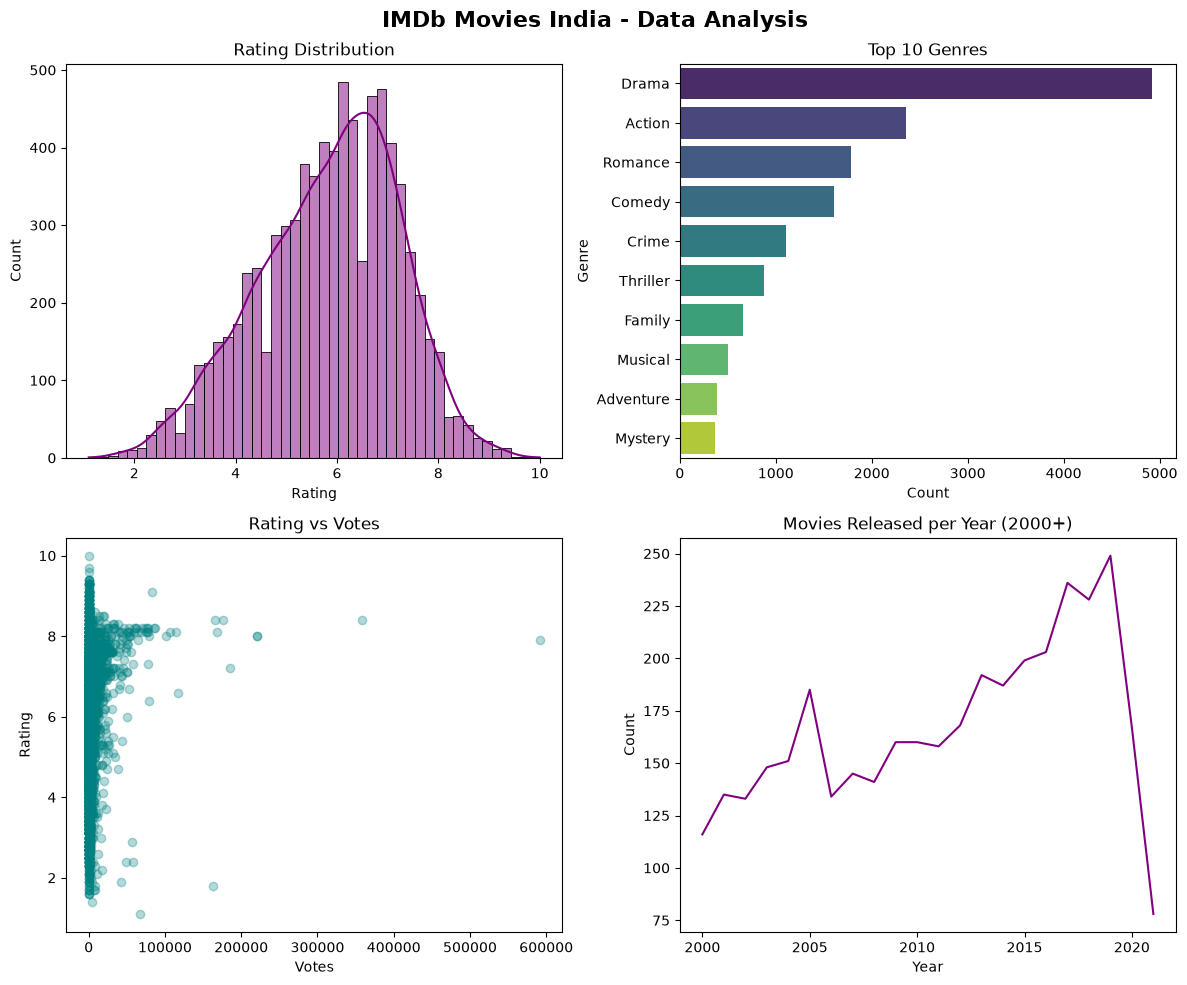

In [6]:
# ============================================
# STEP 5 - DATA VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('IMDb Movies India - Data Analysis', 
             fontsize=16, fontweight='bold')

# Graph 1 - Rating Distribution
sns.histplot(df['Rating'], kde=True, 
             color='purple', ax=axes[0,0])
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# Graph 2 - Top 10 Genres
genre_counts = df['Genre'].str.split(',').explode().str.strip()
top_genres = genre_counts.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, 
            palette='viridis', ax=axes[0,1],
            hue=top_genres.index, legend=False)
axes[0,1].set_title('Top 10 Genres')
axes[0,1].set_xlabel('Count')

# Graph 3 - Rating vs Votes
axes[1,0].scatter(df['Votes'], df['Rating'], 
                  alpha=0.3, color='teal')
axes[1,0].set_title('Rating vs Votes')
axes[1,0].set_xlabel('Votes')
axes[1,0].set_ylabel('Rating')

# Graph 4 - Movies per Year
movies_per_year = df['Year'].value_counts().sort_index()
movies_per_year = movies_per_year[movies_per_year.index >= 2000]
axes[1,1].plot(movies_per_year.index, 
               movies_per_year.values, color='purple')
axes[1,1].set_title('Movies Released per Year (2000+)')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 6 - FEATURE ENGINEERING
# ============================================

# Label Encoding
le = LabelEncoder()

# Genre - pehla genre lo (Drama, Comedy → Drama)
df['Genre'] = df['Genre'].str.split(',').str[0].str.strip()
df['Genre_encoded'] = le.fit_transform(df['Genre'])
print("✅ Genre encoded!")

# Director encode karo
df['Director_encoded'] = le.fit_transform(df['Director'])
print("✅ Director encoded!")

# Actor 1 encode karo
df['Actor1_encoded'] = le.fit_transform(df['Actor 1'])
print("✅ Actor 1 encoded!")

# Actor 2 encode karo
df['Actor2_encoded'] = le.fit_transform(df['Actor 2'])
print("✅ Actor 2 encoded!")

# Actor 3 encode karo
df['Actor3_encoded'] = le.fit_transform(df['Actor 3'])
print("✅ Actor 3 encoded!")

# Final Features select karo
features = ['Year', 'Duration', 'Votes', 
            'Genre_encoded', 'Director_encoded',
            'Actor1_encoded', 'Actor2_encoded', 
            'Actor3_encoded']

X = df[features]
y = df['Rating']

print(f" Features Shape: {X.shape}")
print(f" Target Shape: {y.shape}")
print(f"\n Features used: {features}")
print(f"\n Target (Rating) Stats:")
print(y.describe())

✅ Genre encoded!
✅ Director encoded!
✅ Actor 1 encoded!
✅ Actor 2 encoded!
✅ Actor 3 encoded!

✅ Features Shape: (7919, 8)
✅ Target Shape: (7919,)

📊 Features used: ['Year', 'Duration', 'Votes', 'Genre_encoded', 'Director_encoded', 'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']

📊 Target (Rating) Stats:
count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [ ]:
# ============================================
# STEP 7 - TRAIN TEST SPLIT + MODEL BUILDING
# ============================================

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f" Training Set: {X_train.shape}")
print(f" Testing Set:  {X_test.shape}")

# MODEL 1 - Linear Regression
print("\n" + "=" * 45)
print(" MODEL 1 - LINEAR REGRESSION")
print("=" * 45)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2  = r2_score(y_test, lr_predictions)

print(f"MAE    : {lr_mae:.4f}")
print(f"MSE    : {lr_mse:.4f}")
print(f"RMSE   : {np.sqrt(lr_mse):.4f}")
print(f"R2     : {lr_r2:.4f}")

# MODEL 2 - Random Forest Regressor
print("\n" + "=" * 45)
print(" MODEL 2 - RANDOM FOREST REGRESSOR")
print("=" * 45)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print(f"MAE    : {rf_mae:.4f}")
print(f"MSE    : {rf_mse:.4f}")
print(f"RMSE   : {np.sqrt(rf_mse):.4f}")
print(f"R2     : {rf_r2:.4f}")

# Comparison
print("\n" + "=" * 45)
print(" MODEL COMPARISON")
print("=" * 45)
print(f"{'Model':<25} {'R2':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 45)
print(f"{'Linear Regression':<25} {lr_r2:>8.4f} {lr_mae:>8.4f} {np.sqrt(lr_mse):>8.4f}")
print(f"{'Random Forest':<25} {rf_r2:>8.4f} {rf_mae:>8.4f} {np.sqrt(rf_mse):>8.4f}")

winner = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"\n Winner: {winner}")

✅ Training Set: (6335, 8)
✅ Testing Set:  (1584, 8)

📊 MODEL 1 - LINEAR REGRESSION
MAE    : 1.0395
MSE    : 1.6943
RMSE   : 1.3016
R2     : 0.0887

📊 MODEL 2 - RANDOM FOREST REGRESSOR
MAE    : 0.8355
MSE    : 1.2288
RMSE   : 1.1085
R2     : 0.3391

🏆 MODEL COMPARISON
Model                           R2      MAE     RMSE
---------------------------------------------
Linear Regression           0.0887   1.0395   1.3016
Random Forest               0.3391   0.8355   1.1085

🥇 Winner: Random Forest


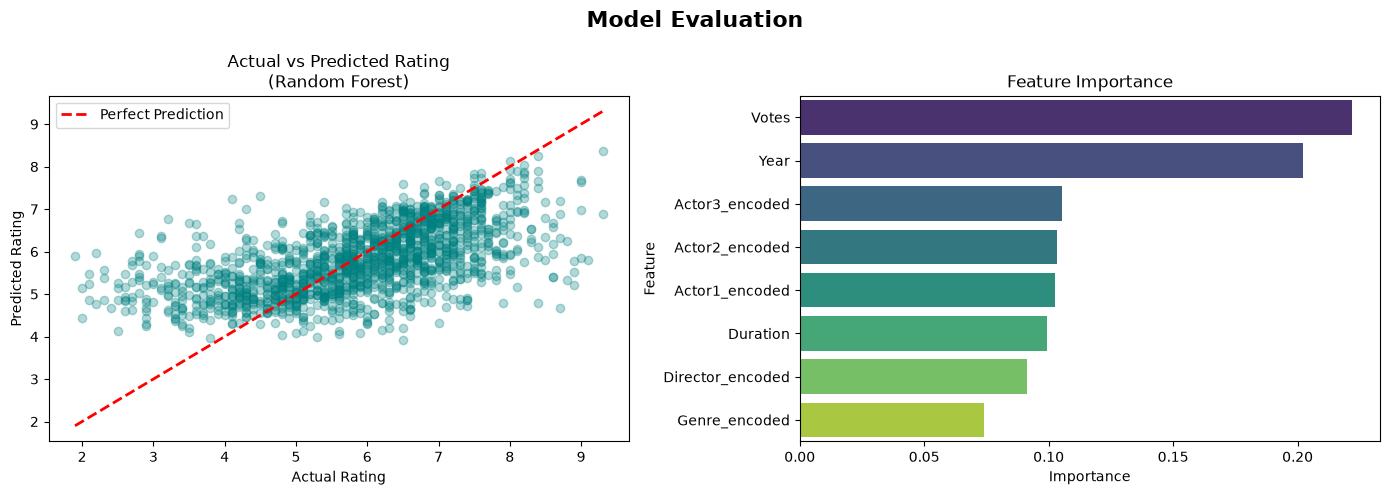


🎬 MOVIE RATING PREDICTOR

Movie 1: 2023, Popular (50K votes)
Predicted Rating: 5.6/10 ⭐⭐⭐⭐⭐⭐
---------------------------------------------
Movie 2: 2020, Medium (1K votes)
Predicted Rating: 5.6/10 ⭐⭐⭐⭐⭐⭐
---------------------------------------------
Movie 3: 2015, Niche  (200 votes)
Predicted Rating: 5.3/10 ⭐⭐⭐⭐⭐
---------------------------------------------


In [ ]:
# ============================================
# STEP 8 - VISUALIZATION + PREDICTION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# Graph 1 - Actual vs Predicted (Random Forest)
axes[0].scatter(y_test, rf_predictions, alpha=0.3, color='teal')
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Actual vs Predicted Rating\n(Random Forest)')
axes[0].legend()

# Graph 2 - Feature Importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature',
            data=feature_importance,
            hue='Feature', palette='viridis', 
            legend=False, ax=axes[1])
axes[1].set_title('Feature Importance')
plt.tight_layout()
plt.show()

# Real Prediction Demo
print("\n MOVIE RATING PREDICTOR")
print("=" * 45)

new_movies = pd.DataFrame({
    'Year':             [2023,  2020,  2015 ],
    'Duration':         [150,   120,   180  ],
    'Votes':            [50000, 1000,  200  ],
    'Genre_encoded':    [3,     1,     5    ],
    'Director_encoded': [100,   50,    200  ],
    'Actor1_encoded':   [500,   200,   800  ],
    'Actor2_encoded':   [300,   150,   600  ],
    'Actor3_encoded':   [200,   100,   400  ]
})

movies_info = [
    "Movie 1: 2023, Popular (50K votes)",
    "Movie 2: 2020, Medium (1K votes)",
    "Movie 3: 2015, Niche  (200 votes)"
]

predictions = rf_model.predict(new_movies)

print()
for info, pred in zip(movies_info, predictions):
    stars = "⭐" * int(round(pred))
    print(f"{info}")
    print(f"Predicted Rating: {pred:.1f}/10 {stars}")
    print("-" * 45)